# 03_Road_Network_Analysis

## GramSathi AI: An Intelligent Geospatial Decision Support System for Rural Infrastructure Planning

### Objective

In this notebook, we analyze the downloaded road network to understand its structure, connectivity, and characteristics.

The extracted insights will later be used for infrastructure gap analysis and machine learning.

### Goals

* Load the saved road network.
* Analyze nodes and edges.
* Calculate total road length.
* Identify road types.
* Generate descriptive statistics.
* Prepare features for AI models.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [2]:
# Load road network data

nodes = gpd.read_file("../datasets/raw/road_nodes.geojson")
edges = gpd.read_file("../datasets/raw/road_edges.geojson")

print("Data Loaded Successfully!")

Data Loaded Successfully!


In [3]:
print("Nodes Shape :", nodes.shape)
print("Edges Shape :", edges.shape)

Nodes Shape : (1654, 5)
Edges Shape : (3985, 17)


In [4]:
edges.head()

,u,v,key,osmid,highway,oneway,reversed,length,lanes,maxspeed,ref,name,bridge,junction,access,tunnel,geometry
0,459895642,1437357973,0,130531802,[secondary],False,False,23.926465,None,None,None,None,None,None,None,None,"LINESTRING (74.1176 14.87427, 74.11782 14.87426)"
1,459895642,2587876974,0,252756143,[trunk],True,False,21.618649,[2],[80; 50],NH66,None,None,None,None,None,"LINESTRING (74.1176 14.87427, 74.11775 14.87414)"
2,459895642,6827206857,0,838172115,[secondary],False,True,17.264330,None,None,None,None,None,None,None,None,"LINESTRING (74.1176 14.87427, 74.11744 14.87425)"
3,459895656,459898359,0,252751925,[primary],True,False,141.184593,[2],[80],None,[Old NH16],None,None,None,None,"LINESTRING (74.1143 14.79168, 74.11422 14.7913..."
4,459895656,2631553817,0,252751930,[primary],False,False,958.057782,[2],[80],None,[Old NH16],None,None,None,None,"LINESTRING (74.1143 14.79168, 74.11462 14.7924..."


In [5]:
# Display all available columns

print("Columns in Road Network Dataset:\n")

for column in edges.columns:
    print(column)

Columns in Road Network Dataset:

u
v
key
osmid
highway
oneway
reversed
length
lanes
maxspeed
ref
name
bridge
junction
access
tunnel
geometry


In [6]:
# ==========================================
# Basic Information About Road Dataset
# ==========================================

print("Road Dataset Information")
print("-" * 40)

edges.info()

Road Dataset Information
----------------------------------------
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3985 entries, 0 to 3984
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   u         3985 non-null   int64   
 1   v         3985 non-null   int64   
 2   key       3985 non-null   int32   
 3   osmid     3985 non-null   object  
 4   highway   3985 non-null   object  
 5   oneway    3985 non-null   bool    
 6   reversed  3985 non-null   object  
 7   length    3985 non-null   float64 
 8   lanes     234 non-null    object  
 9   maxspeed  179 non-null    object  
 10  ref       284 non-null    object  
 11  name      162 non-null    object  
 12  bridge    48 non-null     object  
 13  junction  10 non-null     object  
 14  access    41 non-null     object  
 15  tunnel    6 non-null      object  
 16  geometry  3985 non-null   geometry
dtypes: bool(1), float64(1), geometry(1), int32(1), int64(2

In [7]:
# ==========================================
# Statistical Summary
# ==========================================

edges.describe(include='all')

,u,v,key,osmid,highway,oneway,reversed,length,lanes,maxspeed,ref,name,bridge,junction,access,tunnel,geometry
count,3.985000e+03,3.985000e+03,3985.000000,3985.0,3985,3985,3985,3985.000000,234,179,284,162,48,10,41,6,3985
unique,NaN,NaN,NaN,1013.0,25,2,3,NaN,4,7,3,10,1,1,3,1,3985
top,NaN,NaN,NaN,123721846.0,[residential],False,False,NaN,[2],[80],NH66,[Kaiga Road],yes,roundabout,permissive,yes,"LINESTRING (74.1176024 14.8742694, 74.1178248 ..."
freq,NaN,NaN,NaN,68.0,2439,3624,2150,NaN,227,106,139,58,48,10,26,6,1
mean,8.246454e+09,8.259382e+09,0.006023,NaN,NaN,NaN,NaN,255.041682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4.452654e+09,4.449096e+09,0.077381,NaN,NaN,NaN,NaN,471.404837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,4.598956e+08,4.598956e+08,0.000000,NaN,NaN,NaN,NaN,2.267268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,4.109837e+09,4.109876e+09,0.000000,NaN,NaN,NaN,NaN,50.107424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,9.571736e+09,9.571736e+09,0.000000,NaN,NaN,NaN,NaN,113.177447,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.279711e+10,1.279711e+10,0.000000,NaN,NaN,NaN,NaN,247.290903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# ==========================================
# Total Road Length
# ==========================================

total_length = edges["length"].sum()

print(f"Total Road Length : {total_length:.2f} meters")
print(f"Total Road Length : {total_length/1000:.2f} km")

Total Road Length : 1016341.10 meters
Total Road Length : 1016.34 km


In [9]:
# ==========================================
# Count Road Types
# ==========================================

road_types = edges["highway"].explode().value_counts()

print(road_types)

highway
residential       2449
tertiary           616
unclassified       349
primary            181
secondary          141
trunk              141
living_street       94
trunk_link          18
tertiary_link        6
secondary_link       2
road                 2
Name: count, dtype: int64


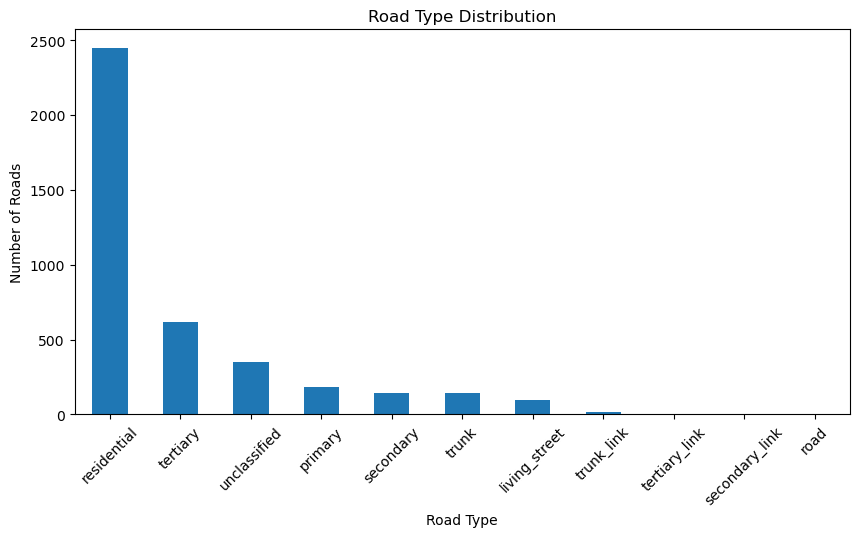

In [10]:
# ==========================================
# Road Type Distribution
# ==========================================

road_types.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Road Type Distribution")
plt.xlabel("Road Type")
plt.ylabel("Number of Roads")

plt.xticks(rotation=45)

plt.show()

In [11]:
# ==========================================
# Top 10 Longest Roads
# ==========================================

edges[["name", "length", "highway"]].sort_values(
    by="length",
    ascending=False
).head(10)

,name,length,highway
3552,None,5696.993260,[unclassified]
3479,None,5696.993260,[unclassified]
2455,None,5296.241171,[primary]
482,None,5296.241171,[primary]
904,"[Siddar Kinnar Road, Siddara Road, Kinnara Road]",4811.810921,[secondary]
2467,"[Siddar Kinnar Road, Kinnara Road, Siddara Road]",4811.810921,[secondary]
900,None,4665.741793,[tertiary]
896,None,4665.741793,[tertiary]
480,None,4545.242593,[primary]
483,None,4545.242593,[primary]


In [12]:
# ==========================================
# Missing Values
# ==========================================

missing = edges.isnull().sum()

print(missing)

u              0
v              0
key            0
osmid          0
highway        0
oneway         0
reversed       0
length         0
lanes       3751
maxspeed    3806
ref         3701
name        3823
bridge      3937
junction    3975
access      3944
tunnel      3979
geometry       0
dtype: int64


In [13]:
# ==========================================
# Average Road Length
# ==========================================

average_length = edges["length"].mean()

print(f"Average Road Length : {average_length:.2f} meters")

Average Road Length : 255.04 meters


In [14]:
# ==========================================
# Shortest and Longest Roads
# ==========================================

print(f"Shortest Road : {edges['length'].min():.2f} meters")
print(f"Longest Road  : {edges['length'].max():.2f} meters")

Shortest Road : 2.27 meters
Longest Road  : 5696.99 meters


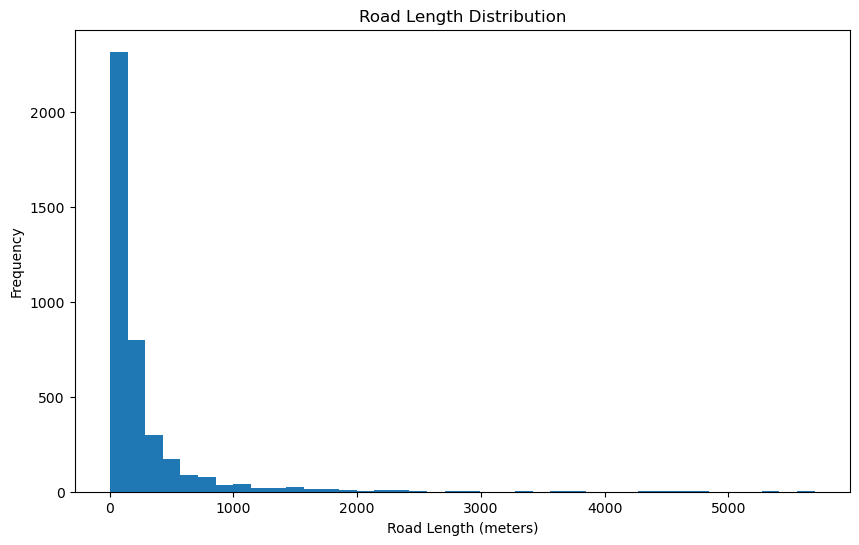

In [15]:
# ==========================================
# Road Length Distribution
# ==========================================

plt.figure(figsize=(10,6))

plt.hist(edges["length"], bins=40)

plt.title("Road Length Distribution")

plt.xlabel("Road Length (meters)")

plt.ylabel("Frequency")

plt.show()

In [16]:
# ==========================================
# Percentage of Each Road Type
# ==========================================

road_percentage = (
    edges["highway"]
    .explode()
    .value_counts(normalize=True)
    * 100
)

print(road_percentage.round(2))

highway
residential       61.24
tertiary          15.40
unclassified       8.73
primary            4.53
secondary          3.53
trunk              3.53
living_street      2.35
trunk_link         0.45
tertiary_link      0.15
secondary_link     0.05
road               0.05
Name: proportion, dtype: float64


In [17]:
# ==========================================
# Save Road Statistics
# ==========================================

road_statistics = {
    "Total Roads": len(edges),
    "Total Junctions": len(nodes),
    "Total Road Length (km)": edges["length"].sum()/1000,
    "Average Road Length (m)": edges["length"].mean(),
    "Maximum Road Length (m)": edges["length"].max(),
    "Minimum Road Length (m)": edges["length"].min()
}

road_statistics

{'Total Roads': 3985,
 'Total Junctions': 1654,
 'Total Road Length (km)': np.float64(1016.3411021182521),
 'Average Road Length (m)': np.float64(255.04168183644973),
 'Maximum Road Length (m)': 5696.993260379204,
 'Minimum Road Length (m)': 2.267268287713341}

# Road Connectivity Intelligence

In this section, we move beyond descriptive statistics and analyze the structure of the road network.

The objective is to identify connectivity patterns that will later help the AI recommend infrastructure improvements.

In [18]:
# ==========================================
# Import NetworkX
# ==========================================

import networkx as nx

print("NetworkX Loaded Successfully ✅")

NetworkX Loaded Successfully ✅


In [19]:
# ==========================================
# Graph Statistics
# ==========================================

print("========== GRAPH STATISTICS ==========")

print(f"Total Nodes : {road_network.number_of_nodes()}")

print(f"Total Edges : {road_network.number_of_edges()}")

print(f"Graph Density : {nx.density(road_network):.6f}")

========== GRAPH STATISTICS ==========


NameError: name 'road_network' is not defined

In [21]:
# ==========================================
# Load Saved Graph
# ==========================================

import osmnx as ox

road_network = ox.load_graphml(
    "../datasets/raw/road_network.graphml"
)

print("✅ Road Network Loaded Successfully!")

✅ Road Network Loaded Successfully!


In [22]:
# ==========================================
# Graph Statistics
# ==========================================

import networkx as nx

print("========== GRAPH STATISTICS ==========")

print(f"Total Nodes : {road_network.number_of_nodes()}")
print(f"Total Edges : {road_network.number_of_edges()}")
print(f"Graph Density : {nx.density(road_network):.6f}")

========== GRAPH STATISTICS ==========
Total Nodes : 1654
Total Edges : 3985
Graph Density : 0.001458


In [23]:
# ==========================================
# Connected Components
# ==========================================

components = list(nx.weakly_connected_components(road_network))

print(f"Connected Components : {len(components)}")

Connected Components : 1


In [24]:
# ==========================================
# Dead-End Junctions
# ==========================================

degrees = dict(road_network.degree())

dead_ends = sum(1 for d in degrees.values() if d == 1)

print(f"Dead-End Junctions : {dead_ends}")

Dead-End Junctions : 1


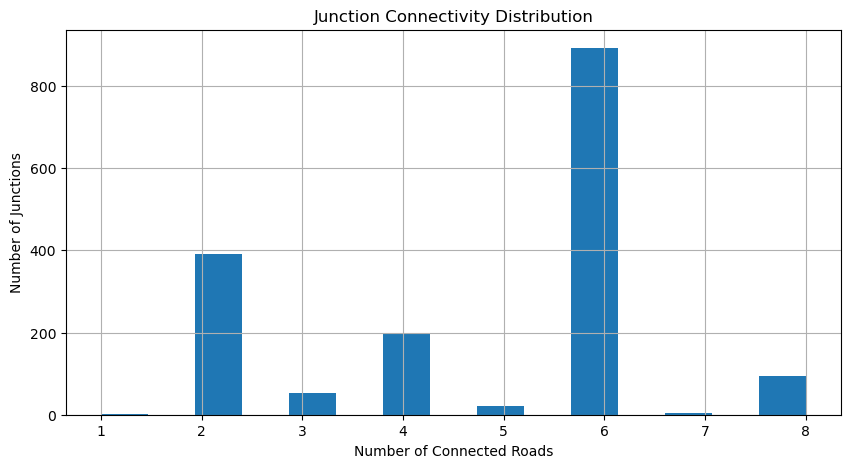

In [25]:
# ==========================================
# Junction Connectivity Distribution
# ==========================================

degree_values = list(degrees.values())

plt.figure(figsize=(10,5))

plt.hist(degree_values, bins=15)

plt.title("Junction Connectivity Distribution")

plt.xlabel("Number of Connected Roads")

plt.ylabel("Number of Junctions")

plt.grid(True)

plt.show()

# Road Connectivity Intelligence

The purpose of this section is to identify critical characteristics of the road network.

These features will later contribute to the Infrastructure Readiness Index (IRI) and the Machine Learning model.

In [26]:
# ==========================================
# Top 10 Longest Roads
# ==========================================

longest_roads = edges.sort_values(
    by="length",
    ascending=False
)[["name", "highway", "length"]]

longest_roads.head(10)

,name,highway,length
3552,None,[unclassified],5696.993260
3479,None,[unclassified],5696.993260
2455,None,[primary],5296.241171
482,None,[primary],5296.241171
904,"[Siddar Kinnar Road, Siddara Road, Kinnara Road]",[secondary],4811.810921
2467,"[Siddar Kinnar Road, Kinnara Road, Siddara Road]",[secondary],4811.810921
900,None,[tertiary],4665.741793
896,None,[tertiary],4665.741793
480,None,[primary],4545.242593
483,None,[primary],4545.242593


In [27]:
# ==========================================
# Average Road Length by Road Type
# ==========================================

road_length_type = (
    edges
    .explode("highway")
    .groupby("highway")["length"]
    .mean()
    .sort_values(ascending=False)
)

road_length_type

highway
road              867.393491
primary           627.492829
trunk             553.766999
unclassified      429.692327
secondary         406.657901
tertiary          307.377177
residential       172.220958
living_street     147.645668
secondary_link     22.511508
tertiary_link      22.054524
trunk_link         16.151535
Name: length, dtype: float64

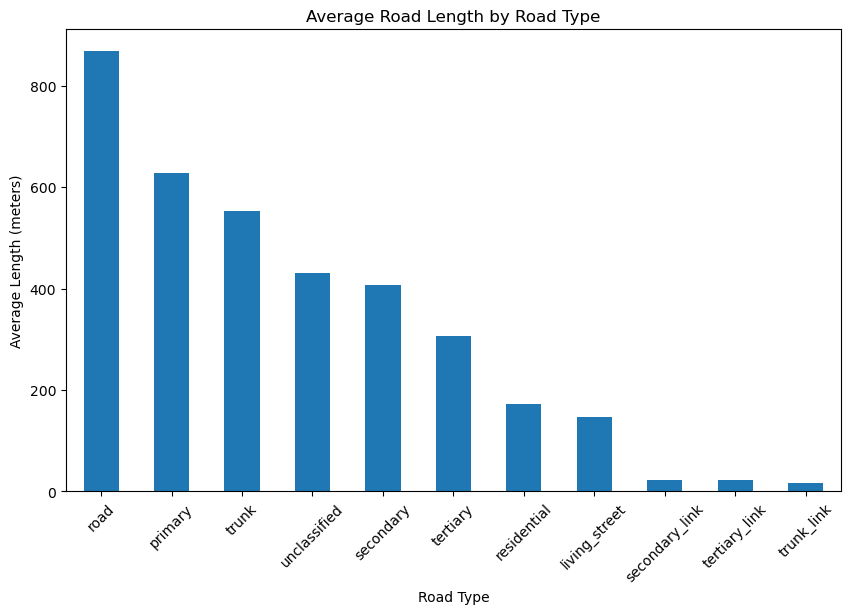

In [28]:
plt.figure(figsize=(10,6))

road_length_type.plot(kind="bar")

plt.title("Average Road Length by Road Type")

plt.xlabel("Road Type")

plt.ylabel("Average Length (meters)")

plt.xticks(rotation=45)

plt.show()

In [29]:
# ==========================================
# Roads Without Names
# ==========================================

unnamed = edges["name"].isna().sum()

print(f"Unnamed Roads : {unnamed}")

Unnamed Roads : 3823


In [30]:
named = len(edges) - unnamed

percentage = (named / len(edges)) * 100

print(f"Named Roads : {percentage:.2f}%")

Named Roads : 4.07%
